# Chapter Number Sequence — Visual Checker
Visualises `chapter_number` progressions for **full** and **interim** constitutions in `sections_v2.csv`.

In [1]:
import csv
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

CSV_PATH = Path("../output/sections_v2.csv")

In [2]:
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
print(df.shape)
df.head(3)

(2810, 19)


,section_id,doc_id,doc_type,year_th,year_ce,name_short,era,regime_type,parent_doc_id,chapter_number,chapter_title,sub_section_number,sub_section_title,section_number,section_role,target_chapter,target_section_no,change_mode,text
0,const_2475_s_1,const_2475,full,2475,1932,Constitution 2475,early_democracy,civilian,NaN,0,บททั่วไป,NaN,NaN,1,content,NaN,NaN,content,สยามประเทศเป็นราชอาณาจักรอันหนึ่งอันเดียว จะแบ...
1,const_2475_s_2,const_2475,full,2475,1932,Constitution 2475,early_democracy,civilian,NaN,0,บททั่วไป,NaN,NaN,2,content,NaN,NaN,content,อำนาจอธิปไตยย่อมมาจากปวงชนชาวสยาม พระมหากษัตริ...
2,const_2475_s_3,const_2475,full,2475,1932,Constitution 2475,early_democracy,civilian,NaN,1,พระมหากษัตริย์,NaN,NaN,3,content,NaN,NaN,content,องค์พระมหากษัตริย์ดำรงอยู่ในฐานะอันเป็นที่เคาร...


## 1 · Section count per document (full & interim)

/var/folders/mb/pnwt1wh177lc4ny5xbs_cyxc0000gn/T/ipykernel_23641/389264045.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts["doc_id"], rotation=45, ha="right", fontsize=8)


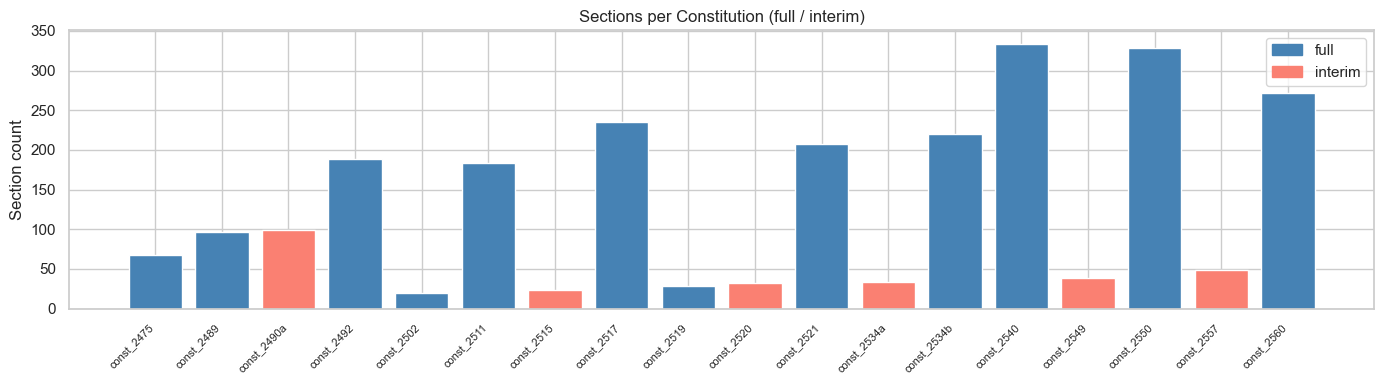

In [3]:
fi = df[df["doc_type"].isin(["full", "interim"])].copy()
counts = fi.groupby(["doc_id", "doc_type"]).size().reset_index(name="sections")
counts = counts.sort_values("doc_id")

palette = {"full": "steelblue", "interim": "salmon"}
colors = counts["doc_type"].map(palette)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(counts["doc_id"], counts["sections"], color=colors)
ax.set_xticklabels(counts["doc_id"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Section count")
ax.set_title("Sections per Constitution (full / interim)")
patches = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
ax.legend(handles=patches)
plt.tight_layout()
plt.show()

## 2 · Chapter number distribution per document (box plot)

/var/folders/mb/pnwt1wh177lc4ny5xbs_cyxc0000gn/T/ipykernel_23641/2677025038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/mb/pnwt1wh177lc4ny5xbs_cyxc0000gn/T/ipykernel_23641/2677025038.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=45, ha="right", fontsize=8)


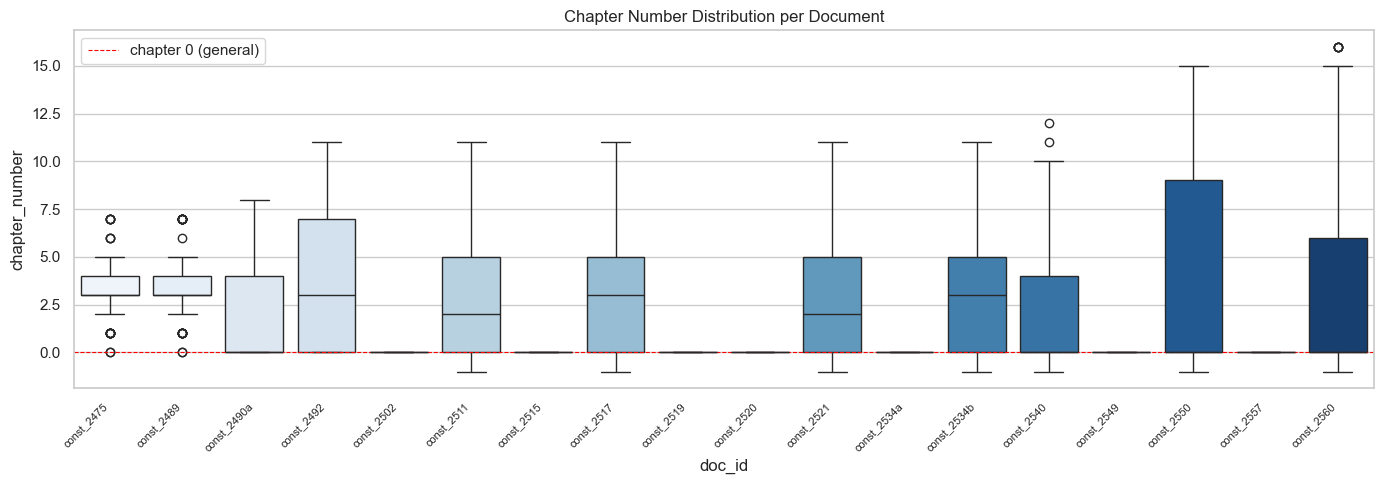

In [4]:
fi["chapter_number"] = pd.to_numeric(fi["chapter_number"], errors="coerce")

order = sorted(fi["doc_id"].unique())
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(
    data=fi, x="doc_id", y="chapter_number",
    order=order, ax=ax, palette="Blues"
)
ax.axhline(0, color="red", linewidth=0.8, linestyle="--", label="chapter 0 (general)")
ax.set_xticklabels(order, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("chapter_number")
ax.set_title("Chapter Number Distribution per Document")
ax.legend()
plt.tight_layout()
plt.show()

## 3 · Sequence transition heatmap (chapter per section index)
Each row = one document. X-axis = section index within that doc. Colour = chapter number.

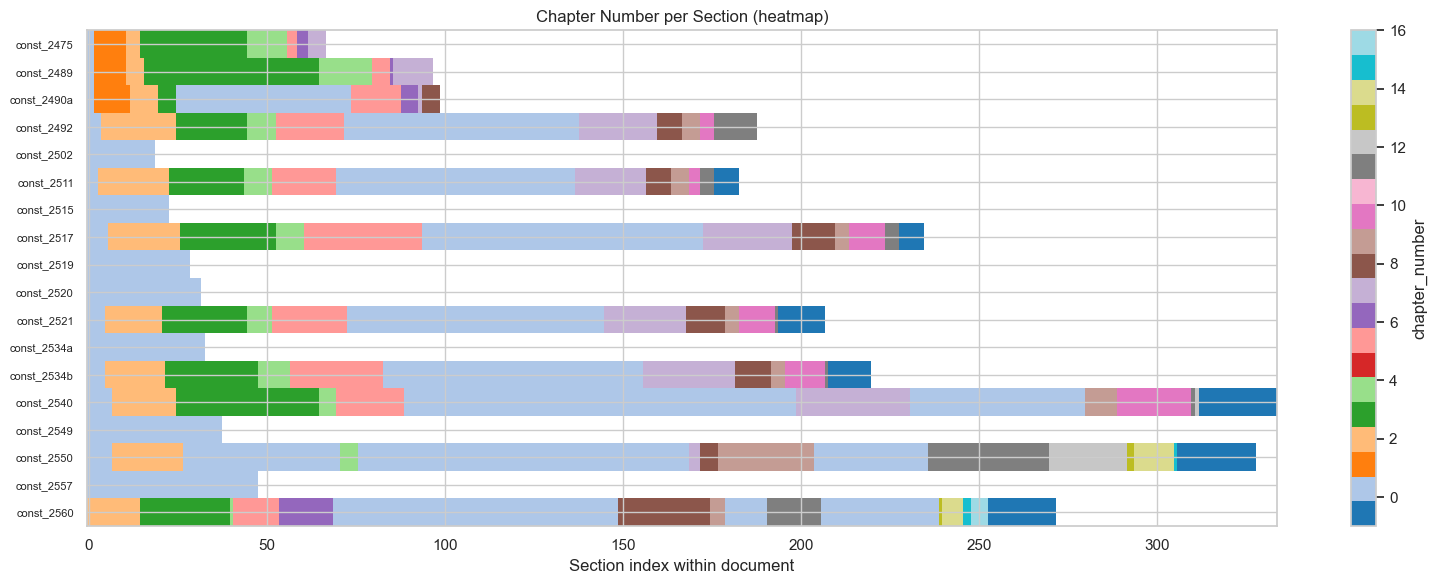

In [5]:
docs = sorted(fi["doc_id"].unique())
max_len = fi.groupby("doc_id").size().max()

matrix = np.full((len(docs), max_len), np.nan)
for i, doc_id in enumerate(docs):
    chaps = fi[fi["doc_id"] == doc_id]["chapter_number"].values
    matrix[i, : len(chaps)] = chaps

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(matrix, aspect="auto", cmap="tab20", vmin=-1, vmax=16)
ax.set_yticks(range(len(docs)))
ax.set_yticklabels(docs, fontsize=8)
ax.set_xlabel("Section index within document")
ax.set_title("Chapter Number per Section (heatmap)")
plt.colorbar(im, ax=ax, label="chapter_number")
plt.tight_layout()
plt.show()

## 4 · Sequence anomaly detection
Flags `bad_start` (doesn't begin at 0), `jump` (skips a chapter), `drop` (chapter decreases non-reset), and `-1` (special/transitory sections).

In [6]:
anomaly_counts = defaultdict(lambda: defaultdict(int))
subsection_anomaly_counts = defaultdict(lambda: defaultdict(int))

for doc_id in docs:
    sub = fi[fi["doc_id"] == doc_id].reset_index(drop=True)

    # Chapter progression checks
    chaps_num = [int(c) if pd.notna(c) else None for c in sub["chapter_number"].tolist()]
    if chaps_num and chaps_num[0] != 0:
        anomaly_counts[doc_id]["bad_start"] += 1

    for prev, curr in zip(chaps_num, chaps_num[1:]):
        if prev is None or curr is None:
            anomaly_counts[doc_id]["null"] += 1
        elif curr == -1:
            anomaly_counts[doc_id]["-1 (special)"] += 1
        elif curr == prev + 1 or curr == 0:
            pass
        elif curr < prev:
            anomaly_counts[doc_id]["drop"] += 1
        elif curr > prev + 1:
            anomaly_counts[doc_id]["jump"] += 1

    # Sub-section progression checks
    # Rule: when chapter stays the same, sub_section_number should rise by +1.
    # When chapter changes, sub_section_number reset is allowed.
    sub_nums = pd.to_numeric(sub["sub_section_number"], errors="coerce").tolist()
    chap_nums = pd.to_numeric(sub["chapter_number"], errors="coerce").tolist()

    prev_ch = None
    prev_ss = None
    seen_subsection = False

    for idx, (curr_ch, curr_ss) in enumerate(zip(chap_nums, sub_nums)):
        if pd.isna(curr_ss):
            prev_ch, prev_ss = curr_ch, curr_ss
            continue

        curr_ss_int = int(curr_ss)
        if not seen_subsection:
            if curr_ss_int not in (0, 1):
                subsection_anomaly_counts[doc_id]["bad_start"] += 1
            seen_subsection = True

        if pd.notna(prev_ss):
            prev_ss_int = int(prev_ss)
            same_chapter = (
                pd.notna(curr_ch)
                and pd.notna(prev_ch)
                and int(curr_ch) == int(prev_ch)
            )

            if same_chapter:
                if curr_ss_int == prev_ss_int + 1:
                    pass
                elif curr_ss_int < prev_ss_int:
                    subsection_anomaly_counts[doc_id]["drop"] += 1
                elif curr_ss_int > prev_ss_int + 1:
                    subsection_anomaly_counts[doc_id]["jump"] += 1

        prev_ch, prev_ss = curr_ch, curr_ss

anomaly_df = pd.DataFrame(anomaly_counts).T.fillna(0).astype(int)
anomaly_df = anomaly_df.reindex(index=docs).fillna(0).astype(int)

subsection_anomaly_df = pd.DataFrame(subsection_anomaly_counts).T.fillna(0).astype(int)
subsection_anomaly_df = subsection_anomaly_df.reindex(index=docs).fillna(0).astype(int)

print("Chapter anomaly summary")
display(anomaly_df)
print("Sub-section anomaly summary (non-null values only)")
display(subsection_anomaly_df)



Chapter anomaly summary


,jump,-1 (special),bad_start
const_2475,0,0,0
const_2489,0,0,0
const_2490a,1,0,0
const_2492,2,0,0
const_2502,0,0,0
const_2511,2,7,0
const_2515,0,0,0
const_2517,2,7,0
const_2519,0,0,0
const_2520,0,0,0


Sub-section anomaly summary (non-null values only)


,bad_start
const_2475,0
const_2489,0
const_2490a,1
const_2492,1
const_2502,0
const_2511,1
const_2515,0
const_2517,1
const_2519,0
const_2520,0


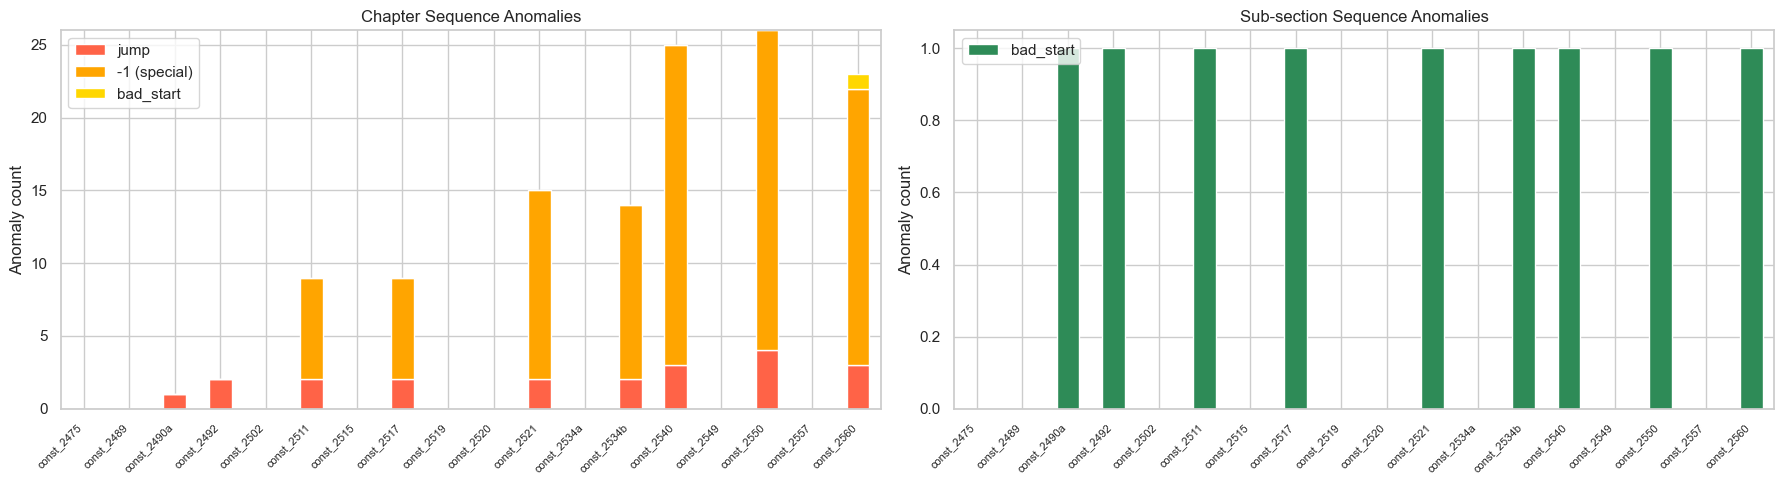

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

if anomaly_df.empty or anomaly_df.values.sum() == 0:
    axes[0].text(0.5, 0.5, "No chapter anomalies found.", ha="center", va="center")
    axes[0].set_axis_off()
else:
    anomaly_df.plot(
        kind="bar", stacked=True, ax=axes[0],
        color=["tomato", "orange", "gold", "orchid", "steelblue"]
    )
    axes[0].set_xticklabels(anomaly_df.index, rotation=45, ha="right", fontsize=8)
    axes[0].set_ylabel("Anomaly count")
    axes[0].set_title("Chapter Sequence Anomalies")

if subsection_anomaly_df.empty or subsection_anomaly_df.values.sum() == 0:
    axes[1].text(0.5, 0.5, "No sub-section anomalies found.", ha="center", va="center")
    axes[1].set_axis_off()
else:
    subsection_anomaly_df.plot(
        kind="bar", stacked=True, ax=axes[1],
        color=["seagreen", "darkorange", "mediumpurple"]
    )
    axes[1].set_xticklabels(subsection_anomaly_df.index, rotation=45, ha="right", fontsize=8)
    axes[1].set_ylabel("Anomaly count")
    axes[1].set_title("Sub-section Sequence Anomalies")

plt.tight_layout()
plt.show()



## 5 · Per-document line chart — chapter progression
Shows exact chapter_number value at each section index for each constitution.

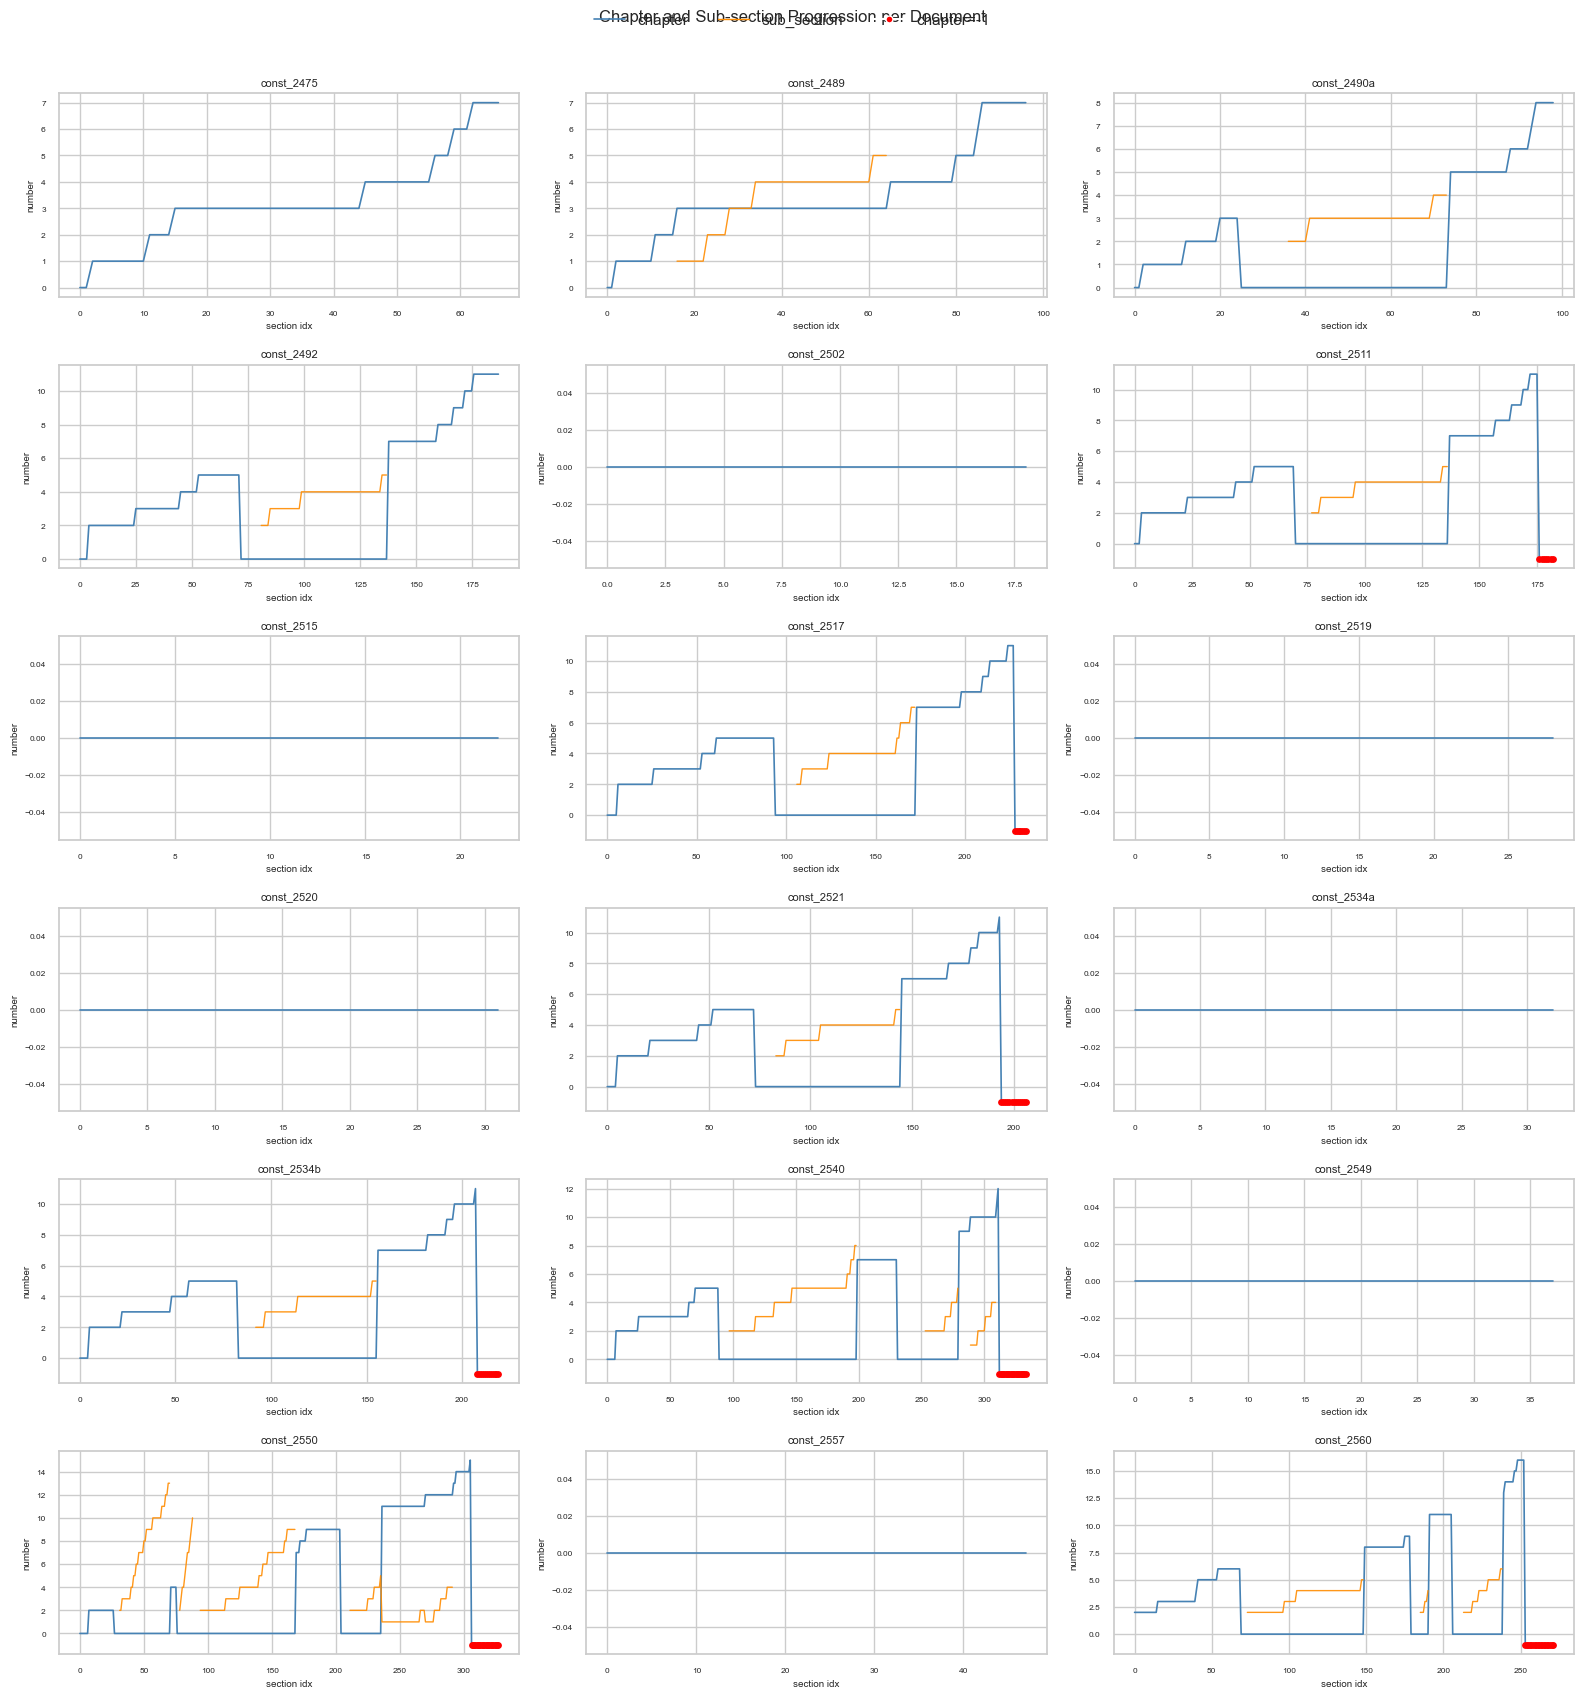

In [8]:
ncols = 3
nrows = int(np.ceil(len(docs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 2.8))
axes = axes.flatten()

for i, doc_id in enumerate(docs):
    sub = fi[fi["doc_id"] == doc_id].reset_index(drop=True)
    ax = axes[i]

    ax.plot(sub.index, sub["chapter_number"], linewidth=1.2, color="steelblue", label="chapter")
    ss = pd.to_numeric(sub["sub_section_number"], errors="coerce")
    ax.plot(sub.index, ss, linewidth=1.0, color="darkorange", alpha=0.9, label="sub_section")

    neg = sub[sub["chapter_number"] == -1]
    ax.scatter(neg.index, neg["chapter_number"], color="red", s=15, zorder=5, label="chapter=-1")

    ax.set_title(doc_id, fontsize=8)
    ax.set_xlabel("section idx", fontsize=7)
    ax.set_ylabel("number", fontsize=7)
    ax.tick_params(labelsize=6)

# hide unused subplots
for j in range(len(docs), len(axes)):
    axes[j].set_visible(False)

handles = [
    plt.Line2D([0], [0], color="steelblue", lw=1.2, label="chapter"),
    plt.Line2D([0], [0], color="darkorange", lw=1.0, label="sub_section"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="red", markersize=5, label="chapter=-1"),
]
fig.legend(handles=handles, loc="upper center", ncol=3, frameon=False)
fig.suptitle("Chapter and Sub-section Progression per Document", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

